# 2. Data Understanding

Sumber data: **Sentinel-5P TROPOMI**, koleksi `SENTINEL_5P_L2` di Copernicus
Data Space Ecosystem (openEO).

## 2.1 Deskripsi fitur

| Kolom | Deskripsi | Satuan | Sumber pada citra satelit |
|---|---|---|---|
| `date` | tanggal observasi (harian, sesuai lintasan satelit) | YYYY-MM-DD | metadata produk |
| `no2` | kerapatan kolom troposferik NO2, dirata-ratakan di dalam polygon Desa Bundah | mol/m² | band `tropospheric_NO2_column_number_density` |
| `co` | kerapatan kolom total CO, dirata-ratakan di dalam polygon Desa Bundah | mol/m² | band `CO_column_number_density` |

### Apa itu NO2 (nitrogen dioksida)?

Gas coklat-kemerahan hasil pembakaran suhu tinggi. Sumber utamanya:
knalpot kendaraan bermotor, mesin diesel (termasuk kapal nelayan di
wilayah pesisir seperti Bundah), pembangkit listrik berbahan bakar fosil,
dan pembakaran biomassa/lahan pertanian. NO2 juga berperan sebagai
prekursor pembentukan ozon troposferik dan hujan asam. WHO menetapkan
ambang batas paparan NO2 karena efeknya pada saluran pernapasan.

### Apa itu CO (karbon monoksida)?

Gas tak berwarna, tak berbau, hasil pembakaran **tidak sempurna** bahan
bakar berbasis karbon. Sumbernya mirip NO2 (kendaraan, mesin diesel,
pembangkit listrik), ditambah sumber rumah tangga seperti tungku kayu/arang,
serta kebakaran hutan dan lahan (karhutla) — relevan untuk musim kemarau
di Madura saat sisa jerami sering dibakar. CO berbahaya karena mengikat
hemoglobin lebih kuat daripada oksigen.

### Kenapa cuma NO2 & CO?

Karena keduanya paling relevan dengan sumber emisi lokal desa
(transportasi, mesin diesel, pembakaran biomassa) dan tersedia harian dari
Sentinel-5P. Polutan lain dari sensor yang sama (SO2, O3, CH4, aerosol
index) bisa ditambahkan dengan cara yang sama persis kalau instruktur minta
lebih banyak fitur.

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../data/kualitas_udara_bundah_sreseh.csv", parse_dates=["date"])
df.head()

,date,no2,co
0,2025-09-01,0.000014,0.028432
1,2025-09-02,0.000016,0.023283
2,2025-09-03,0.000011,0.024006
3,2025-09-04,0.000033,0.029112
4,2025-09-05,0.000019,0.031187


## 2.2 Eksplorasi data seluas-luasnya

In [10]:
df.describe(include="all")

,date,no2,co
count,362,190.000000,172.000000
mean,2026-03-01 03:54:41.767955968,0.000021,0.028697
min,2025-09-01 00:00:00,-0.000022,0.014774
25%,2025-11-30 06:00:00,0.000013,0.025846
50%,2026-03-01 12:00:00,0.000020,0.028716
75%,2026-05-30 18:00:00,0.000028,0.031054
max,2026-08-29 00:00:00,0.000052,0.038664
std,NaN,0.000011,0.003667


In [11]:
total_hari = len(df)
ada_no2 = df["no2"].notna().sum()
ada_co  = df["co"].notna().sum()

print(f"Total hari dalam rentang    : {total_hari}")
print(f"Hari dengan data NO2 valid  : {ada_no2}  ({ada_no2/total_hari:.1%})")
print(f"Hari dengan data CO valid   : {ada_co}  ({ada_co/total_hari:.1%})")
print(f"Hari NO2 kosong (NaN)       : {total_hari - ada_no2}  ({(total_hari-ada_no2)/total_hari:.1%})")
print(f"Hari CO kosong (NaN)        : {total_hari - ada_co}  ({(total_hari-ada_co)/total_hari:.1%})")

Total hari dalam rentang    : 362
Hari dengan data NO2 valid  : 190  (52.5%)
Hari dengan data CO valid   : 172  (47.5%)
Hari NO2 kosong (NaN)       : 172  (47.5%)
Hari CO kosong (NaN)        : 190  (52.5%)


Dari hasil crawling, sekitar **separuh hari dalam setahun tidak punya
data valid** (NO2 dan CO). Ini jumlah yang besar, tapi wajar untuk data
satelit optik seperti Sentinel-5P — dibahas lebih lanjut di bagian 2.3.

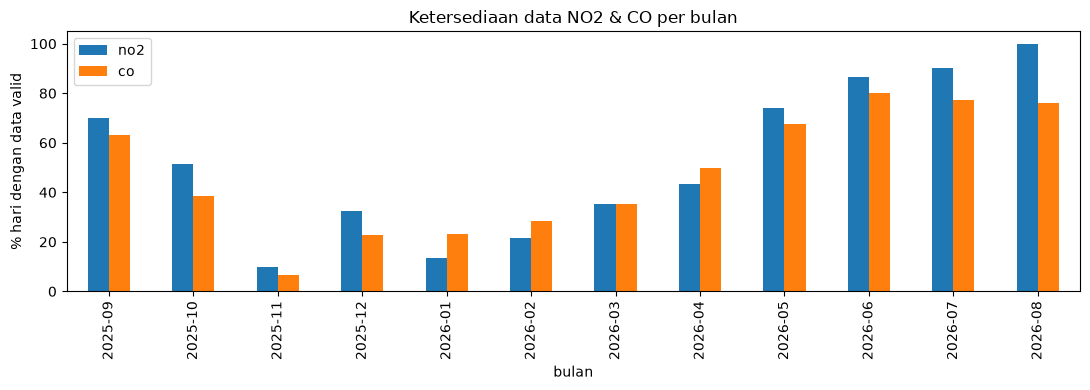

In [12]:
# Ketersediaan data per bulan - untuk melihat apakah kekosongan data terkonsentrasi
# di musim tertentu (mis. musim hujan) atau tersebar merata
df["bulan"] = df["date"].dt.to_period("M")
ketersediaan_bulanan = df.groupby("bulan")[["no2", "co"]].apply(lambda x: x.notna().mean() * 100)

fig, ax = plt.subplots(figsize=(11, 4))
ketersediaan_bulanan.plot(kind="bar", ax=ax)
ax.set_ylabel("% hari dengan data valid")
ax.set_title("Ketersediaan data NO2 & CO per bulan")
plt.tight_layout()
plt.show()

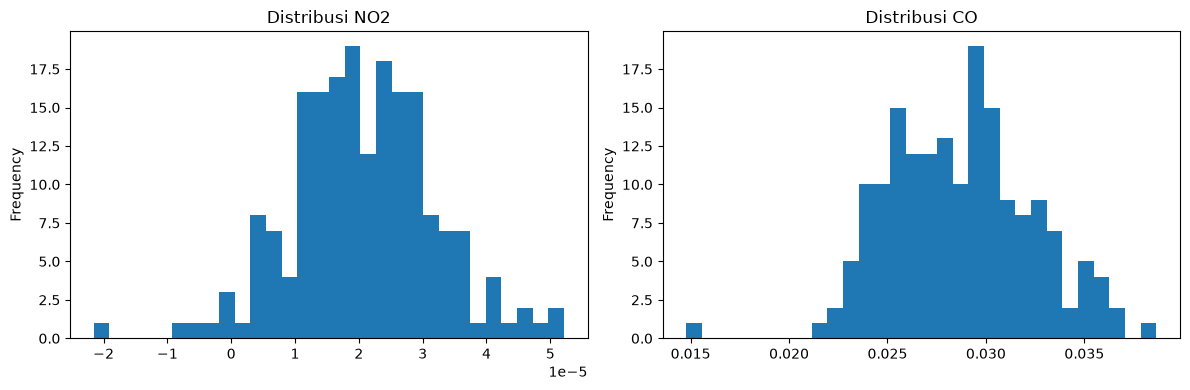

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df["no2"].plot(kind="hist", bins=30, ax=axes[0], title="Distribusi NO2")
df["co"].plot(kind="hist", bins=30, ax=axes[1], title="Distribusi CO")
plt.tight_layout()
plt.show()

In [14]:
# NO2 dan CO sama-sama produk pembakaran, jadi wajar kalau berkorelasi
df[["no2", "co"]].corr()

,no2,co
no2,1.000000,0.053631
co,0.053631,1.000000


## 2.3 Apakah ada data yang aneh?

Tiga jenis kejanggalan yang wajar ditemukan pada data satelit seperti ini,
dan bukan berarti data rusak:

1. **Banyak nilai kosong (NaN) — sekitar separuh hari dalam setahun.**
   Sentinel-5P adalah sensor optik pasif, jadi tidak bisa "menembus" awan
   tebal. Hari-hari mendung penuh otomatis tidak menghasilkan pengukuran
   yang valid, dan Desa Bundah beriklim tropis muson dengan tutupan awan
   cukup sering sepanjang tahun. Grafik ketersediaan bulanan di atas bisa
   dipakai untuk mengecek apakah kekosongan memang lebih parah di bulan
   basah (± November–April) dibanding bulan kering.
2. **Pola time series yang terlihat "terputus-putus" (gap berkelompok),**
   bukan cuma bolong satu-dua hari acak. Ini konsisten dengan kombinasi
   siklus revisit satelit dan periode berawan berturut-turut, bukan
   indikasi proses crawling yang gagal — selama polanya cocok dengan
   ekspektasi musiman, ini bisa dianggap wajar.
3. **Nilai NO2 sedikit negatif** pada beberapa hari (lihat cell di bawah).
   Wajar terjadi pada area dengan emisi sangat rendah (pedesaan, jauh dari
   kota besar) — ini derau (noise) dari algoritma retrieval satelit, bukan
   error fatal, selama masih dalam rentang uncertainty yang wajar
   (biasanya didokumentasikan di metadata produk Sentinel-5P).

In [15]:
# Cek hari-hari dengan NO2 negatif (noise retrieval, bukan emisi negatif secara fisik)
df[df["no2"] < 0][["date", "no2"]]

,date,no2
14,2025-09-15,-2.154770e-05
41,2025-10-12,-6.750936e-06
47,2025-10-18,-8.838073e-07
242,2026-05-02,-2.794744e-06
277,2026-06-06,-7.910086e-06
337,2026-08-05,-8.928915e-07


In [16]:
# Tandai baris dengan kemungkinan lonjakan (contoh sederhana: > mean + 2*std)
threshold_no2 = df["no2"].mean() + 2 * df["no2"].std()
lonjakan = df[df["no2"] > threshold_no2]
lonjakan[["date", "no2"]]

,date,no2
246,2026-05-06,0.000045
262,2026-05-22,0.000052
269,2026-05-29,0.000046
278,2026-06-07,0.000048
279,2026-06-08,0.000052


**Catatan interpretasi:** kalau tanggal-tanggal lonjakan di atas
berkumpul menjelang akhir musim kemarau (± Juni–Agustus), ini kemungkinan
berkaitan dengan pembakaran lahan/jerami pasca panen — cocokkan dengan
kalender tanam padi di Madura untuk memperkuat dugaan ini. Kalau
tersebar acak sepanjang tahun tanpa pola musiman, kemungkinan besar itu
murni variasi/derau alami data satelit.